**Intalling and importing the libraries that will be used in these operations**

**Task 1:** Framework Setup and Environment Configuration.
Set up a working PyTorch environment on your local machine or Google Colab. Create a Python script/notebook that accomplishes the following:
1: Install PyTorch
2: Import essential libraries: NumPy, Matplotlib, and any other libraries you'll use in tasks

**Task 2:** Tensor Operations and Manipulations
Create a Jupyter notebook or Python script named tensor_operations.py demonstrating your understanding of PyTorch tensors. Include the following operations with appropriate code comments:
#### Basic Operations:
           1: Create tensors using at least three different methods (e.g., from lists, random initialization, zeros/ones)
           2: Demonstrate tensor reshaping, slicing, and indexing operations
           3: Show examples of tensor concatenation and stacking
#### Mathematical Operations:
           1: Perform element-wise operations (addition, multiplication, division)          
           2: Implement matrix multiplication using appropriate PyTorch functions
           3: Calculate mean, sum, and standard deviation of tensors
           4: Demonstrate broadcasting with tensors of different shapes
#### Gradient Computation:
           1: Create tensors with requires_grad=True
           2: Perform operations and compute gradients using .backward()
           3: Show how to access and interpret gradients
           4: Demonstrate gradient zeroing and why it's necessary

**Task 3:** Simple Neural Network Implementation
Build a simple feedforward neural network using PyTorch to solve a classification problem. You may use any standard dataset such as MNIST, Fashion-MNIST, or create a synthetic dataset using scikit-learn (e.g., make_classification or make_moons).
Your implementation should include
#### Network Architecture
           1: Define a neural network class inheriting from nn.Module           2: Implement at least one hidden layer with appropriate activation function
           3: Include an output layer suitable for your classification task
#### Training Pipeline
           1: Load and preprocess your chosen dataset
           2: Define an appropriate loss function and optimizer
           3: Implement the complete training loop with proper forward pass, loss calculation, backward pass, and parameter updates
           4: Track and store training loss for each epoch
#### Evaluation and Visualization
           1: Evaluate your model on test data and report accuracy
           2: Plot the training loss curve across epochs
           3: Display at least 5 sample predictions with their true labels

## Code Quality:
1: Use clear variable names and proper code structure
2: Include comments explaining key sections
3: Handle data shapes and dimensions correctly

Note: All Python scripts and Jupyter notebooks with properly executed outputs

In [ ]:
!pip install numpy
!pip install matplotlib
!pip install torch

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt


from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("PyTorch version:", torch.__version__)
print("NumPy version:", np.__version__)


PyTorch version: 2.9.0+cpu
NumPy version: 2.0.2


**Tensor Basic Operations and Manipulations**

In [ ]:
# Creating tensor using torch
t_list = torch.tensor([1,2,3,4,5])
print("Tensor list: ", t_list)
print("Data type of tensor list: ", t_list.dtype)
print("Shape of tensor list: ", t_list.shape)

# creating tensor using random method
rand_t = torch.rand(3, 4)
print("Random tensor: ", rand_t)
print("Shape:", rand_t.shape)

# creating tensor using zeros and ones
zeros_t = torch.zeros(2, 3)
print("Zeros tensor: ", zeros_t)
print("Shape: ", zeros_t.shape)

ones_t = torch.ones(2, 2, 2)
print("Ones tensor: ", ones_t)
print("Shape:", ones_t.shape)

# creating tensor using numpy
np_array = np.array([[10, 20, 30], [40, 50, 60]])
np_tensor = torch.from_numpy(np_array)
print("Tensor using numpy: ", np_tensor)
print("Shape: ", np_tensor.shape)

Tensor list:  tensor([1, 2, 3, 4, 5])
Data type of tensor list:  torch.int64
Shape of tensor list:  torch.Size([5])
Random tensor:  tensor([[0.7877, 0.3137, 0.2713, 0.9629],
        [0.0659, 0.2994, 0.5806, 0.8512],
        [0.2187, 0.6486, 0.8454, 0.4580]])
Shape: torch.Size([3, 4])
Zeros tensor:  tensor([[0., 0., 0.],
        [0., 0., 0.]])
Shape:  torch.Size([2, 3])
Ones tensor:  tensor([[[1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.]]])
Shape: torch.Size([2, 2, 2])
Tensor using numpy:  tensor([[10, 20, 30],
        [40, 50, 60]])
Shape:  torch.Size([2, 3])


### Tensor Reshaping, Slicing, and Indexing

In [ ]:
#creating a tensor
new_t = torch.arange(12).reshape(3, 4)
print("Original tensor that will be reshaped: ", new_t)

#Reshaping tensor using different ways
reshaped_tensor1 = new_t.reshape(4, 3)
print("Reshaped tensor: ", reshaped_tensor1)

reshaped_tensor2 = new_t.view(2, 6)
print("Reshaped tensor using view method: ", reshaped_tensor2)

# Reshape to 1D
flat_tensor = t_list.flatten()
print("Flat tensor:", flat_tensor)

# Tensor slicing
print("Tensor slicing: ")
print("First row: ", new_t[0])
print("First column: ", new_t[:, 0])
print("Elements from row 1 onwards, column 2 onwards: ", new_t[1:, 2:])

# Tensor indexing
print("Tensor indexing:")
print("Element at (1, 2): ", new_t[1, 2])

# indexing using a list
print("Elements at (0, 0) and (2, 3): ", new_t[[0, 2], [0, 3]])

# Boolean indexing
print("Elements that are greater than 5: ", new_t[new_t > 5])

Original tensor that will be reshaped:  tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Reshaped tensor:  tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]])
Reshaped tensor using view method:  tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11]])
Flat tensor: tensor([1, 2, 3, 4, 5])
Tensor slicing: 
First row:  tensor([0, 1, 2, 3])
First column:  tensor([0, 4, 8])
Elements from row 1 onwards, column 2 onwards:  tensor([[ 6,  7],
        [10, 11]])
Tensor indexing:
Element at (1, 2):  tensor(6)
Elements at (0, 0) and (2, 3):  tensor([ 0, 11])
Elements that are greater than 5:  tensor([ 6,  7,  8,  9, 10, 11])


### Tensor Concatenation and Stacking

In [ ]:
# Create two tensors
tensor1 = torch.tensor([[1, 2], [3, 4]])
tensor2 = torch.tensor([[5, 6], [7, 8]])
print("Tensor 1: ", tensor1)
print("Tensor 2: ", tensor2)

# Concatenate along rows
concat = torch.cat((tensor1, tensor2), dim=0)
print("Concadenation along rows: ", concat)

# Concatenate along columns
concat_col = torch.cat((tensor1, tensor2), dim=1)
print("Concadenation along columns: ", concat_col)

#Tensor stacking
st_tensor = torch.stack((tensor1, tensor2))
print("Stacked tensor: ", st_tensor)
print("Shape of stacked tensor: ", st_tensor.shape)


Tensor 1:  tensor([[1, 2],
        [3, 4]])
Tensor 2:  tensor([[5, 6],
        [7, 8]])
Concadenation along rows:  tensor([[1, 2],
        [3, 4],
        [5, 6],
        [7, 8]])
Concadenation along columns:  tensor([[1, 2, 5, 6],
        [3, 4, 7, 8]])
Stacked tensor:  tensor([[[1, 2],
         [3, 4]],

        [[5, 6],
         [7, 8]]])
Shape of stacked tensor:  torch.Size([2, 2, 2])


## Mathematical Operations

### Element-wise Operations (Addition, Multiplication, Division)

In [ ]:
t1 = torch.tensor([[1, 2], [3, 4]])
t2 = torch.tensor([[5, 6], [7, 8]])

print("Tensor 1: ", t1)
print("Tensor 2: ", t2)

#tensor addition
addition = torch.add(t1, t2)
print("Element wise tensor addition: ", addition)

mul = torch.mul(t1, t2)
print("Element wise tensor multiplication: ", mul)

division = torch.div(t1, t2)
print("Element wise tensor division: " , division)

Tensor 1:  tensor([[1, 2],
        [3, 4]])
Tensor 2:  tensor([[5, 6],
        [7, 8]])
Element wise tensor addition:  tensor([[ 6,  8],
        [10, 12]])
Element wise tensor multiplication:  tensor([[ 5, 12],
        [21, 32]])
Element wise tensor division:  tensor([[0.2000, 0.3333],
        [0.4286, 0.5000]])


### Matrix Multiplication

In [ ]:
#creating matrix
m1 = torch.tensor([[1, 2], [3, 4]])
m2 = torch.tensor([[5, 6], [7, 8]])

print("Matrix 1: ", m1)
print("Matrix 2: ", m2)

mat_multiplication = torch.matmul(m1, m2)
print("Matrix multiplication: ", mat_multiplication)


Matrix 1:  tensor([[1, 2],
        [3, 4]])
Matrix 2:  tensor([[5, 6],
        [7, 8]])
Matrix multiplication:  tensor([[19, 22],
        [43, 50]])


### Statistical Operations (Mean, Sum, Standard Deviation)

In [ ]:
tensor = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0], [7.0, 8.0, 9.0]])
print("Tensor", tensor)

# Mean
mean_val = torch.mean(tensor)
print("Mean Value: ", mean_val)

# Sum
sum_val = torch.sum(tensor)
print("Sum value: ", sum_val)

#Standard Deviation
std_val = torch.std(tensor)
print("Standard deviation: ", std_val)


Tensor tensor([[1., 2., 3.],
        [4., 5., 6.],
        [7., 8., 9.]])
Mean Value:  tensor(5.)
Sum value:  tensor(45.)
Standard deviation:  tensor(2.7386)


### Broadcasting

In [ ]:
tensor = torch.tensor([[1, 2, 3],
                  [4, 5, 6]])
scalar = torch.tensor(10)
v_row = torch.tensor([10, 20, 30])
v_col = torch.tensor([[10],
                      [20]])

print("Matrix: ", tensor)
print("Scalar: ", scalar)
print("Row vector: ", v_row)
print("Column vector: ", v_col)

# Broadcasting
print("tensor + scalar: ", tensor + scalar)
print("tensor + row ", tensor + v_row)
print("tensor + column: ", tensor + v_col)

Matrix:  tensor([[1, 2, 3],
        [4, 5, 6]])
Scalar:  tensor(10)
Row vector:  tensor([10, 20, 30])
Column vector:  tensor([[10],
        [20]])
tensor + scalar:  tensor([[11, 12, 13],
        [14, 15, 16]])
tensor + row  tensor([[11, 22, 33],
        [14, 25, 36]])
tensor + column:  tensor([[11, 12, 13],
        [24, 25, 26]])


## Gradient Computation

### 1. Create Tensors using requires_grad=True

In [ ]:
# creating a tensor using req_grad
x = torch.tensor(2.0, requires_grad=True)

print("Tensor created")
print("x: ", x)
print("requires_grad: ", x.requires_grad)


Tensor created
x:  tensor(2., requires_grad=True)
requires_grad:  True


### 2. Perform Operations and Compute Gradients using `.backward()`

In [ ]:
# defining a funtion
y = x**2 + 3*x

print("Operation performed: ")
print("y: ", y)

#computing gradient
y.backward()

Operation performed: 
y:  tensor(10., grad_fn=<AddBackward0>)


### 3. Access and Interpret Gradients

In [ ]:
print("Access Gradient")
print("Gradient: ", x.grad)

print("Interpretation:")
print("Formula: y = x^2 + 3x")
print("Derivative: dy/dx = 2x + 3")

# Manually calculating expected gradient
print("Expected value: ", 2*x.item() + 3)
print("PyTorch value: ", x.grad.item())


Access Gradient
Gradient:  tensor(14.)
Interpretation:
Formula: y = x^2 + 3x
Derivative: dy/dx = 2x + 3
Expected value:  7.0
PyTorch value:  14.0


### 4. Demonstrate Gradient Zeroing and Why It's Necessary

In [ ]:
# Performing backward again
print("gradient accumulation")
y = x**2 + 3*x
y.backward()

print("Gradient after second backward: " , x.grad)
# zeroing gradient
x.grad.zero_()
print("After zeroing gradient =", x.grad)

print("Why zeroing is necessary: ")
print("Because PyTorch adds gradients every time backward() is called.")
print("We must reset gradients before next calculation.")

gradient accumulation
Gradient after second backward:  tensor(14.)
After zeroing gradient = tensor(0.)
Why zeroing is necessary: 
Because PyTorch adds gradients every time backward() is called.
We must reset gradients before next calculation.


**Task 3: Simple Neural Network Implementation**

Network architecture and training pipeline

In [ ]:
# generating moon dataset --- binary classification
x, y = make_moons(n_samples=1000, noise=0.2, random_state=42)

#splitting intro train test
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#scalling features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#converting numpy array to tensor
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)


In [ ]:
# defining neural network layers
hidden_layer = nn.Linear(2, 10)
relu = nn.ReLU()
output_layer = nn.Linear(10, 2)

In [ ]:
# loss function
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = optim.Adam(
    list(hidden_layer.parameters()) +
    list(output_layer.parameters()),
    lr=0.01
)

In [ ]:
# training epochs and process
epochs = 50
losses = []
for epoch in range(epochs):
    hidden_output = hidden_layer(X_train)
    activated = relu(hidden_output)
    final_output = output_layer(activated)
    loss = criterion(final_output, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 10, Loss: 0.5370
Epoch 20, Loss: 0.4063
Epoch 30, Loss: 0.3145
Epoch 40, Loss: 0.2811
Epoch 50, Loss: 0.2666


### Evaluating Model

In [ ]:
# evaluation
with torch.no_grad():
    hidden_output = hidden_layer(X_test)
    activated = relu(hidden_output)
    final_output = output_layer(activated)
    _, predicted = torch.max(final_output, 1)
    accuracy = (predicted == y_test).sum().item() / len(y_test)
    print("Test Accuracy:", accuracy * 100, "%")

Test Accuracy: 87.0 %


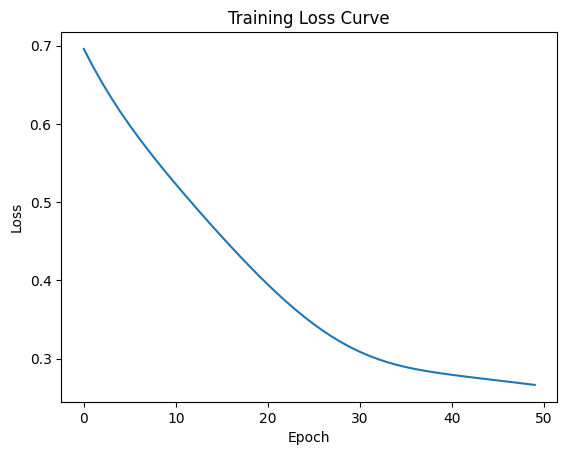

In [ ]:
# plotting training loss curve
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
# showing some sample predictions

print("Sample Predictions: ")
for i in range(5):
    sample = X_test[i]
    hidden_output = hidden_layer(sample)
    activated = relu(hidden_output)
    final_output = output_layer(activated)
    _, pred = torch.max(final_output, 0)
    print(f"Sample {i+1}: Predicted = {pred.item()}, True = {y_test[i].item()}")

Sample Predictions: 
Sample 1: Predicted = 1, True = 1
Sample 2: Predicted = 0, True = 0
Sample 3: Predicted = 1, True = 1
Sample 4: Predicted = 0, True = 0
Sample 5: Predicted = 1, True = 1
